In [98]:
import warnings                    ## Handling warnings
import numpy as np                 ## linear algebra
import pandas as pd                ## data processing
import matplotlib.pyplot as plt    ## visualization
import seaborn as sns              ## visualization
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix

import numpy as np
# Preprocessing
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score



In [99]:
import pandas as pd

# Replace 'your_file.xlsx' with the actual file path
df = pd.read_excel('/HLA/HLA  kamel.xlsx')

# Now you can explore the DataFrame 'df'
print(df.head())


   ID    SAL  Age  Diseased:1\nHealty:2  Gender\nM:2\nF:1   A1    A2    B1  \
0   05P  NaN  NaN                   1.0                 1  2.0  11.0  35.0   
1  05B1  NaN  NaN                   2.0                 2  2.0  26.0  35.0   
2  05B2  NaN  NaN                   2.0                 2  2.0  26.0  15.0   
3  05B3  NaN  NaN                   2.0                 2  2.0  11.0  15.0   
4  05S1  NaN  NaN                   2.0                 1  2.0  11.0  15.0   

     B2  C1  C2  DRB1 1  DRB1 2  DRB3  DRB4  DRB5  DQB1 1  DQB1 2  
0  40.0 NaN NaN     1.0    16.0   NaN   NaN   NaN     NaN     NaN  
1   8.0 NaN NaN     1.0     3.0   NaN   NaN   NaN     NaN     NaN  
2   8.0 NaN NaN     3.0    16.0   NaN   NaN   NaN     NaN     NaN  
3  40.0 NaN NaN    16.0    16.0   NaN   NaN   NaN     NaN     NaN  
4  40.0 NaN NaN    16.0    16.0   NaN   NaN   NaN     NaN     NaN  


In [100]:
df.size

7236

In [3]:
!pip install scipy


[notice] A new release of pip is available: 24.0 -> 24.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------------------- ------------------ 30.7/60.8 kB 640.0 kB/s eta 0:00:01
     ------------------- ------------------ 30.7/60.8 kB 640.0 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/60.8 kB 245.8 kB/s eta 0:00:01
     -------------------------------------- 60.8/60.8 kB 293.7 kB/s eta 0:00:00
   ---------------------------------------- 0.0/44.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.7 MB 1.4 MB/s eta 0:00:33
   ---------------------------------------- 0.0/44.7 MB 1.4 MB/s eta 0:00:33
   ---------------------------------------- 0.0/44.7 MB 1.4 MB/s eta 0:00:33
   ---------------------------------------- 0.0/44.7 MB 1.4 MB/s eta 0:00:33
   ---------------------------------------- 0.2/44.7 MB 952.6 kB/s eta 0:00:47
   ---------------------------------------- 0.2/44.7 MB 857.5 kB/s eta 0:00:52
   ---------------------------------------- 0.2/44.7 MB 831.5 kB/s eta 

In [101]:
df.shape

(402, 18)

In [102]:
#were gonna drop the SAL column cause its complitly empty and useless
df.drop("SAL", axis = 1, inplace = True)

In [103]:
df.rename(columns={'Diseased:1\nHealty:2': 'status'}, inplace=True)
df['status'] = df['status'].replace({2: 0})

In [104]:
df['status'].fillna(0, inplace=True)

C:\Users\Shadi\AppData\Local\Temp\ipykernel_7100\271315407.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['status'].fillna(0, inplace=True)


In [105]:
df.rename(columns={'Gender\nM:2\nF:1': 'sex'}, inplace=True)
df['sex'] = df['sex'].replace({1: 0})
df['sex'] = df['sex'].replace({2: 1})

In [107]:
categorical_cols = ['A1', 'A2', 'B1', 'B2', 'C1', 'C2', 'DRB1 1', 'DRB1 2', 'DRB3', 'DRB4', 'DRB5', 'DQB1 1', 'DQB1 2']

# Apply one-hot encoding using pd.get_dummies()
#df_encoded = pd.get_dummies(df, columns=categorical_cols)
df_filled = df
df_filled.columns = df.columns.str.strip()
df_filled.columns

Index(['ID', 'Age', 'status', 'sex', 'A1', 'A2', 'B1', 'B2', 'C1', 'C2',
       'DRB1 1', 'DRB1 2', 'DRB3', 'DRB4', 'DRB5', 'DQB1 1', 'DQB1 2'],
      dtype='object')

In [108]:
categorical_columns=['Age','ID','A1', 'A2', 'B1', 'B2', 'C1', 'C2',
       'DRB1 1', 'DRB1 2', 'DRB3', 'DRB4', 'DRB5', 'DQB1 1', 'DQB1 2']

df_filled = pd.get_dummies(df_filled, columns=categorical_columns, dummy_na=True)
df_filled.head()

,status,sex,Age_2.0,Age_3.0,Age_4.0,Age_6.0,Age_7.0,Age_8.0,Age_9.0,Age_10.0,...,DQB1 1_5.0,DQB1 1_6.0,DQB1 1_nan,DQB1 2_0.0,DQB1 2_2.0,DQB1 2_3.0,DQB1 2_4.0,DQB1 2_5.0,DQB1 2_6.0,DQB1 2_nan
0,1.0,0,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
1,0.0,1,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
2,0.0,1,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
3,0.0,1,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
4,0.0,0,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True


In [79]:
df.shape

(402, 17)

In [109]:
X = df_filled.drop(columns=['status'])
y = df_filled['status']


In [22]:
df_filled.head()

,Age,status,sex,A1,A2,B1,B2,C1,C2,DRB1 1,...,ID _983CH4,ID _983FR1,ID _983FR2,ID _983FR3,ID _983FR4,ID _983FR5,ID _983FR6,ID _983P,ID _983S1,ID _983S2
0,-1.0,1.0,0,2.0,11.0,35.0,40.0,-1.0,-1.0,1.0,...,False,False,False,False,False,False,False,False,False,False
1,-1.0,0.0,0,2.0,26.0,35.0,8.0,-1.0,-1.0,1.0,...,False,False,False,False,False,False,False,False,False,False
2,-1.0,0.0,0,2.0,26.0,15.0,8.0,-1.0,-1.0,3.0,...,False,False,False,False,False,False,False,False,False,False
3,-1.0,0.0,0,2.0,11.0,15.0,40.0,-1.0,-1.0,16.0,...,False,False,False,False,False,False,False,False,False,False
4,-1.0,0.0,0,2.0,11.0,15.0,40.0,-1.0,-1.0,16.0,...,False,False,False,False,False,False,False,False,False,False


model

HistGradientBoostingClassifie handeling null values

In [81]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report


# Split while maintaining class proportions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the HistGradientBoostingClassifier
model = HistGradientBoostingClassifier(max_bins=255, max_iter=100)

# Define hyperparameter grid for tuning
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_leaf': [1, 2, 3]
}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Best Model Test Set Accuracy: {accuracy:.2f}")
print("Classification Report:\n", report)


KeyboardInterrupt: 

In [111]:
# Make predictions on the training set
y_train_pred = best_model.predict(X_train)

# Evaluate the model on the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_report = classification_report(y_train, y_train_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print("Training Classification Report:\n", train_report)


Training Accuracy: 0.84
Training Classification Report:
               precision    recall  f1-score   support

         0.0       0.84      1.00      0.91       267
         1.0       1.00      0.04      0.07        54

    accuracy                           0.84       321
   macro avg       0.92      0.52      0.49       321
weighted avg       0.86      0.84      0.77       321



In [112]:
# Compute the confusion matrix for the training predictions
conf_matrix_train = confusion_matrix(y_train, y_train_pred)

print("Confusion Matrix (Training Set):\n", conf_matrix_train)


Confusion Matrix (Training Set):
 [[267   0]
 [ 52   2]]


other models after dropping nulls

preprosses

In [114]:
df_encoded.dropna(inplace=True)  # This will remove rows with any null values
print(f"The number of rows after dropping null values: {len(df)}")


The number of rows after dropping null values: 402


In [115]:
df_encoded = pd.get_dummies(df_encoded, columns=['A1', 'A2', 'B1', 'B2', 'C1', 'C2', 'DRB1 1', 'DRB1 2', 'DRB3', 'DRB4', 'DRB5', 'DQB1 1', 'DQB1 2'])

In [84]:
# Assuming 'status' is your target column
target_col = 'status'


# Split while maintaining class proportions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [86]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

models = [
    LogisticRegression(),
    RandomForestClassifier(),
    GradientBoostingClassifier(),
    SVC(),
    XGBClassifier(),
    LGBMClassifier(),
    MultinomialNB()
]
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import SGDClassifier

models.extend([
    RandomForestClassifier(max_depth=None,
    min_samples_split=5,
    n_estimators=200,
    random_state=42),
    GradientBoostingClassifier(),
    SGDClassifier(max_iter=1000)
])
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models.extend([
    KNeighborsClassifier(),
    SVC(probability=True),
    XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    LGBMClassifier()
])


 hyperparameter tuning for models that need it

In [87]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grids
param_grids = {
    'LogisticRegression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    },
    'RandomForestClassifier': {
        'n_estimators': [100, 200, 300, 400, 500],
        'max_depth': [None, 5, 10, 15, 20],
        'min_samples_split': [2, 5, 10]
    },
    'GradientBoostingClassifier': {
        'n_estimators': [100, 200, 300, 400, 500],
        'learning_rate': [0.01, 0.1, 1],
        'max_depth': [3, 5, 10]
    },
    'SVC': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'gamma': [0.001, 0.01, 0.1, 1]
    },
    'XGBClassifier': {
        'n_estimators': [100, 200, 300, 400, 500],
        'learning_rate': [0.01, 0.1, 1],
        'max_depth': [3, 5, 10]
    },
    'LGBMClassifier': {
        'n_estimators': [100, 200, 300, 400, 500],
        'learning_rate': [0.01, 0.1, 1],
        'max_depth': [3, 5, 10]
    },
    'MultinomialNB': {
        'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    },
  
    'GaussianNB': {
        'var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 1e-04, 1e-03, 1e-02]
    },
    
    'BernoulliNB': {
        'alpha': [0.001, 0.01, 0.1, 1, 10, 100],
        'binarize': [0.0, 0.5, 1.0]
    }
}
}


# Create a dictionary to store the best models
best_models = {}

for model in models:
    model_name = type(model).__name__
    if model_name in param_grids:
        # Instantiate the grid search model
        grid_search = GridSearchCV(estimator=model, param_grid=param_grids[model_name], cv=5, n_jobs=-1, verbose=2)

        # Fit the grid search to the data
        grid_search.fit(X_train, y_train)

        # Get the best model
        best_models[model_name] = grid_search.best_estimator_
    else:
        # For models that don't need hyperparameter tuning, just use the original model
        best_models[model_name] = model


Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 45 candidates, totalling 225 fits
Fitting 5 folds for each of 28 candidates, totalling 140 fits
Fitting 5 folds for each of 45 candidates, totalling 225 fits
Fitting 5 folds for each of 45 candidates, totalling 225 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 54, number of negative: 267
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 98
[LightGBM] [Info] Number of data points in the train set: 321, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.168224 -> initscore=-1.598265
[LightGBM] [Info] Start training from score -1.598265
[

In [88]:
best_models

{'LogisticRegression': LogisticRegression(C=0.001),
 'RandomForestClassifier': RandomForestClassifier(max_depth=5, random_state=42),
 'GradientBoostingClassifier': GradientBoostingClassifier(learning_rate=0.01),
 'SVC': SVC(C=0.001, gamma=0.001, probability=True),
 'XGBClassifier': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.01, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=100,
               n_jobs=No

In [89]:
from sklearn.metrics import classification_report, confusion_matrix

for model_name, model in best_models.items():
    # Fit the model
    if 'sparse' in model.get_params().get('input', ''):
        model.fit(X_train, y_train)
    else:
        model.fit(X_train.values, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Get the classification report and confusion matrix for the training set
    train_report = classification_report(y_train, y_train_pred)
    train_confusion = confusion_matrix(y_train, y_train_pred)

    # Get the classification report and confusion matrix for the test set
    test_report = classification_report(y_test, y_test_pred)
    test_confusion = confusion_matrix(y_test, y_test_pred)

    print(f"Model: {model_name}\n")
    print("Training set:")
    print("Classification report:\n", train_report)
    print("Confusion matrix:\n", train_confusion)
    print("\nTest set:")
    print("Classification report:\n", test_report)
    print("Confusion matrix:\n", test_confusion)
    print("\n" + "="*80 + "\n")  # print a separator


Model: LogisticRegression

Training set:
Classification report:
               precision    recall  f1-score   support

         0.0       0.83      1.00      0.91       267
         1.0       0.00      0.00      0.00        54

    accuracy                           0.83       321
   macro avg       0.42      0.50      0.45       321
weighted avg       0.69      0.83      0.76       321

Confusion matrix:
 [[267   0]
 [ 54   0]]

Test set:
Classification report:
               precision    recall  f1-score   support

         0.0       0.84      1.00      0.91        68
         1.0       0.00      0.00      0.00        13

    accuracy                           0.84        81
   macro avg       0.42      0.50      0.46        81
weighted avg       0.70      0.84      0.77        81

Confusion matrix:
 [[68  0]
 [13  0]]




C:\Users\Shadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Shadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Shadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Shadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` paramet

Model: RandomForestClassifier

Training set:
Classification report:
               precision    recall  f1-score   support

         0.0       0.83      1.00      0.91       267
         1.0       0.00      0.00      0.00        54

    accuracy                           0.83       321
   macro avg       0.42      0.50      0.45       321
weighted avg       0.69      0.83      0.76       321

Confusion matrix:
 [[267   0]
 [ 54   0]]

Test set:
Classification report:
               precision    recall  f1-score   support

         0.0       0.84      1.00      0.91        68
         1.0       0.00      0.00      0.00        13

    accuracy                           0.84        81
   macro avg       0.42      0.50      0.46        81
weighted avg       0.70      0.84      0.77        81

Confusion matrix:
 [[68  0]
 [13  0]]




C:\Users\Shadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
C:\Users\Shadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
C:\Users\Shadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Shadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_d

Model: GradientBoostingClassifier

Training set:
Classification report:
               precision    recall  f1-score   support

         0.0       0.83      1.00      0.91       267
         1.0       0.00      0.00      0.00        54

    accuracy                           0.83       321
   macro avg       0.42      0.50      0.45       321
weighted avg       0.69      0.83      0.76       321

Confusion matrix:
 [[267   0]
 [ 54   0]]

Test set:
Classification report:
               precision    recall  f1-score   support

         0.0       0.84      0.99      0.91        68
         1.0       0.00      0.00      0.00        13

    accuracy                           0.83        81
   macro avg       0.42      0.49      0.45        81
weighted avg       0.70      0.83      0.76        81

Confusion matrix:
 [[67  1]
 [13  0]]


Model: SVC

Training set:
Classification report:
               precision    recall  f1-score   support

         0.0       0.83      1.00      0.91       2

C:\Users\Shadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Shadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Shadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Model: XGBClassifier

Training set:
Classification report:
               precision    recall  f1-score   support

         0.0       0.83      1.00      0.91       267
         1.0       0.00      0.00      0.00        54

    accuracy                           0.83       321
   macro avg       0.42      0.50      0.45       321
weighted avg       0.69      0.83      0.76       321

Confusion matrix:
 [[267   0]
 [ 54   0]]

Test set:
Classification report:
               precision    recall  f1-score   support

         0.0       0.84      1.00      0.91        68
         1.0       0.00      0.00      0.00        13

    accuracy                           0.84        81
   macro avg       0.42      0.50      0.46        81
weighted avg       0.70      0.84      0.77        81

Confusion matrix:
 [[68  0]
 [13  0]]


[LightGBM] [Info] Number of positive: 54, number of negative: 267
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000118 seconds.

C:\Users\Shadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [110]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

# Define the parameter grids for Naive Bayes classifiers
param_grids = {
    'GaussianNB': {
        'var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 1e-04, 1e-03, 1e-02]
    },
    
    'BernoulliNB': {
        'alpha': [0.001, 0.01, 0.1, 1, 10, 100],
        'binarize': [0.0, 0.5, 1.0]
    }
}

# Create a list of Naive Bayes models
models = [
    GaussianNB(),
    MultinomialNB(),
    BernoulliNB()
]

# Create a dictionary to store the best models
best_models = {}

# Assuming X_train and y_train are already defined
for model in models:
    model_name = type(model).__name__
    if model_name in param_grids:
        # Instantiate the grid search model
        grid_search = GridSearchCV(estimator=model, param_grid=param_grids[model_name], cv=5, n_jobs=-1, verbose=2)

        # Fit the grid search to the data
        grid_search.fit(X_train, y_train)

        # Get the best model
        best_models[model_name] = grid_search.best_estimator_
    else:
        # For models that don't need hyperparameter tuning, just use the original model
        best_models[model_name] = model

# Print the best models
for model_name, best_model in best_models.items():
    print(f"Best model for {model_name}:")
    print(best_model)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best model for GaussianNB:
GaussianNB()
Best model for MultinomialNB:
MultinomialNB()
Best model for BernoulliNB:
BernoulliNB(alpha=0.001, binarize=1.0)


In [111]:

for model_name, model in best_models.items():
    # Fit the model
    if 'sparse' in model.get_params().get('input', ''):
        model.fit(X_train, y_train)
    else:
        model.fit(X_train.values, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Get the classification report and confusion matrix for the training set
    train_report = classification_report(y_train, y_train_pred)
    train_confusion = confusion_matrix(y_train, y_train_pred)

    # Get the classification report and confusion matrix for the test set
    test_report = classification_report(y_test, y_test_pred)
    test_confusion = confusion_matrix(y_test, y_test_pred)

    print(f"Model: {model_name}\n")
    print("Training set:")
    print("Classification report:\n", train_report)
    print("Confusion matrix:\n", train_confusion)
    print("\nTest set:")
    print("Classification report:\n", test_report)
    print("Confusion matrix:\n", test_confusion)
    print("\n" + "="*80 + "\n")  # print a separator


Model: GaussianNB

Training set:
Classification report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       267
         1.0       1.00      1.00      1.00        54

    accuracy                           1.00       321
   macro avg       1.00      1.00      1.00       321
weighted avg       1.00      1.00      1.00       321

Confusion matrix:
 [[267   0]
 [  0  54]]

Test set:
Classification report:
               precision    recall  f1-score   support

         0.0       0.89      0.82      0.85        68
         1.0       0.33      0.46      0.39        13

    accuracy                           0.77        81
   macro avg       0.61      0.64      0.62        81
weighted avg       0.80      0.77      0.78        81

Confusion matrix:
 [[56 12]
 [ 7  6]]


Model: MultinomialNB

Training set:
Classification report:
               precision    recall  f1-score   support

         0.0       0.94      0.92      0.93       267
   

C:\Users\Shadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(
C:\Users\Shadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(
C:\Users\Shadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but MultinomialNB was fitted without feature names
  warnings.warn(
C:\Users\Shadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but MultinomialNB was fitted without feature names
  warnings.warn(
C:\Users\Shadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but BernoulliNB was fitted without feature names
  warnings.warn(
C:\Users\Shadi\AppData\Local

In [121]:
accuracy_scores

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

In [139]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 269 entries, 121 to 401
Columns: 137 entries, Age to DQB1 2_6.0
dtypes: bool(134), float64(2), int64(1)
memory usage: 43.6 KB


In [146]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix

# Convert your DataFrame to PyTorch tensors
X_train_tensor = torch.tensor(X_train.values.astype(np.float32))
y_train_tensor = torch.tensor(y_train.values.astype(np.float32))
X_test_tensor = torch.tensor(X_test.values.astype(np.float32))
y_test_tensor = torch.tensor(y_test.values.astype(np.float32))

# DataLoader
train_data = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_data, batch_size=32)

# model architecture
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid()
)

# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

# Train the model
for epoch in range(10):  # number of epochs
    for inputs, targets in train_loader:
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(), targets)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

# Make predictions on the training set and test set
y_train_pred = (model(X_train_tensor).detach().numpy() > 0.5).astype("int32")
y_test_pred = (model(X_test_tensor).detach().numpy() > 0.5).astype("int32")

# Print the classification report and confusion matrix for the training set
print("Training set:")
print(classification_report(y_train, y_train_pred))
print(confusion_matrix(y_train, y_train_pred))

# Print the classification report and confusion matrix for the test set
print("Test set:")
print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))


Training set:
              precision    recall  f1-score   support

         0.0       0.88      1.00      0.94       189
         1.0       0.00      0.00      0.00        26

    accuracy                           0.88       215
   macro avg       0.44      0.50      0.47       215
weighted avg       0.77      0.88      0.82       215

[[189   0]
 [ 26   0]]
Test set:
              precision    recall  f1-score   support

         0.0       0.87      1.00      0.93        47
         1.0       0.00      0.00      0.00         7

    accuracy                           0.87        54
   macro avg       0.44      0.50      0.47        54
weighted avg       0.76      0.87      0.81        54

[[47  0]
 [ 7  0]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classif

Assigning a higher class weight to the minority class.



In [148]:
from sklearn.utils.class_weight import compute_sample_weight

# Calculate sample weights
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Define the model
model = RandomForestClassifier(n_estimators=100)

# Fit the model with sample weights
model.fit(X_train, y_train, sample_weight=sample_weights)

# Make predictions on the training set and test set
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Print the classification report and confusion matrix for the training set
print("Training set:")
print(classification_report(y_train, y_train_pred))
print(confusion_matrix(y_train, y_train_pred))

# Print the classification report and confusion matrix for the test set
print("Test set:")
print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))


Training set:
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00       189
         1.0       0.96      1.00      0.98        26

    accuracy                           1.00       215
   macro avg       0.98      1.00      0.99       215
weighted avg       1.00      1.00      1.00       215

[[188   1]
 [  0  26]]
Test set:
              precision    recall  f1-score   support

         0.0       0.86      0.94      0.90        47
         1.0       0.00      0.00      0.00         7

    accuracy                           0.81        54
   macro avg       0.43      0.47      0.45        54
weighted avg       0.75      0.81      0.78        54

[[44  3]
 [ 7  0]]


# --- End of HLA (2).ipynb ---

In [ ]:
import warnings                    ## Handling warnings
import numpy as np                 ## linear algebra
import pandas as pd                ## data processing
import matplotlib.pyplot as plt    ## visualization
import seaborn as sns              ## visualization

# Preprocessing
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score



In [ ]:
import pandas as pd

# Replace 'your_file.xlsx' with the actual file path
df = pd.read_excel('/content/HLA  kamel.xlsx')

# Now you can explore the DataFrame 'df'
print(df.head())


   ID    SAL  Age  Diseased:1\nHealty:2  Gender\nM:2\nF:1   A1    A2    B1  \
0   05P  NaN  NaN                   1.0                 1  2.0  11.0  35.0   
1  05B1  NaN  NaN                   2.0                 2  2.0  26.0  35.0   
2  05B2  NaN  NaN                   2.0                 2  2.0  26.0  15.0   
3  05B3  NaN  NaN                   2.0                 2  2.0  11.0  15.0   
4  05S1  NaN  NaN                   2.0                 1  2.0  11.0  15.0   

     B2  C1  C2  DRB1 1  DRB1 2  DRB3  DRB4  DRB5  DQB1 1  DQB1 2  
0  40.0 NaN NaN     1.0    16.0   NaN   NaN   NaN     NaN     NaN  
1   8.0 NaN NaN     1.0     3.0   NaN   NaN   NaN     NaN     NaN  
2   8.0 NaN NaN     3.0    16.0   NaN   NaN   NaN     NaN     NaN  
3  40.0 NaN NaN    16.0    16.0   NaN   NaN   NaN     NaN     NaN  
4  40.0 NaN NaN    16.0    16.0   NaN   NaN   NaN     NaN     NaN  


In [ ]:
df.size

7236

In [ ]:
df.shape

(402, 18)

In [ ]:
#were gonna drop the SAL column cause its complitly empty and useless
df.drop("SAL", axis = 1, inplace = True)

In [ ]:
df.rename(columns={'Diseased:1\nHealty:2': 'status'}, inplace=True)
df['status'] = df['status'].replace({2: 0})

In [ ]:
df['status'].fillna(0, inplace=True)

In [ ]:
df.rename(columns={'Gender\nM:2\nF:1': 'sex'}, inplace=True)
df['sex'] = df['sex'].replace({1: 0})
df['sex'] = df['sex'].replace({2: 1})

In [ ]:
df.dropna(inplace=True)  # This will remove rows with any null values
print(f"The number of rows after dropping null values: {len(df)}")


The number of rows after dropping null values: 269


In [ ]:
categorical_cols = ['A1', 'A2', 'B1', 'B2', 'C1', 'C2', 'DRB1 1', 'DRB1 2', 'DRB3', 'DRB4', 'DRB5', 'DQB1 1', 'DQB1 2']

# Apply one-hot encoding using pd.get_dummies()
#df_encoded = pd.get_dummies(df, columns=categorical_cols)


In [ ]:
df_encoded = df.drop(columns=['ID  '])


In [ ]:
df.shape

(402, 17)

model

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# Split while maintaining class proportions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the HistGradientBoostingClassifier
model = HistGradientBoostingClassifier(max_bins=255, max_iter=100)

# Define hyperparameter grid for tuning
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_leaf': [1, 2, 3]
}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Best Model Test Set Accuracy: {accuracy:.2f}")
print("Classification Report:\n", report)


NameError: name 'target_col' is not defined

In [ ]:
# Make predictions on the training set
y_train_pred = best_model.predict(X_train)

# Evaluate the model on the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_report = classification_report(y_train, y_train_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print("Training Classification Report:\n", train_report)


Training Accuracy: 0.83
Training Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      1.00      0.91       267
         1.0       1.00      0.02      0.04        54

    accuracy                           0.83       321
   macro avg       0.92      0.51      0.47       321
weighted avg       0.86      0.83      0.76       321



In [ ]:
# Compute the confusion matrix for the training predictions
conf_matrix_train = confusion_matrix(y_train, y_train_pred)

print("Confusion Matrix (Training Set):\n", conf_matrix_train)


Confusion Matrix (Training Set):
 [[267   0]
 [ 53   1]]


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
import numpy as np

target_col = 'status'

# Handle categorical columns
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object' and df_encoded[col].isnull().any():
        df_encoded[col].fillna(df_encoded[col].mode()[0], inplace=True)

# Handle numerical columns
for col in df_encoded.columns:
    if df_encoded[col].dtype != 'object' and df_encoded[col].isnull().any():
        imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
        df_encoded[col] = imputer.fit_transform(df_encoded[col].values.reshape(-1,1))[:,0]

X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# Initialize the Decision Tree Classifier with maximum depth
clf = DecisionTreeClassifier(max_depth=3)

# Perform 5-fold cross validation
scores = cross_val_score(clf, X, y, cv=5)
print("Cross-validated scores:", scores)
print("Average score:", scores.mean())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model to the training data
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", report)


Cross-validated scores: [0.24691358 0.75308642 0.8375     0.8375     0.85      ]
Average score: 0.705
Accuracy: 0.80
Classification Report:
               precision    recall  f1-score   support

         0.0       0.81      0.98      0.89        64
         1.0       0.67      0.12      0.20        17

    accuracy                           0.80        81
   macro avg       0.74      0.55      0.54        81
weighted avg       0.78      0.80      0.74        81



In [ ]:
# Make predictions on the training set
y_train_pred = model.predict(X_train)

# Evaluate the model on the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_report = classification_report(y_train, y_train_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print("Training Classification Report:\n", train_report)


Training Accuracy: 0.92
Training Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.94      0.95       271
         1.0       0.70      0.80      0.75        50

    accuracy                           0.92       321
   macro avg       0.83      0.87      0.85       321
weighted avg       0.92      0.92      0.92       321



In [ ]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix for the training predictions
conf_matrix_train = confusion_matrix(y_train, y_train_pred)

print("Confusion Matrix (Training Set):\n", conf_matrix_train)


Confusion Matrix (Training Set):
 [[254  17]
 [ 10  40]]


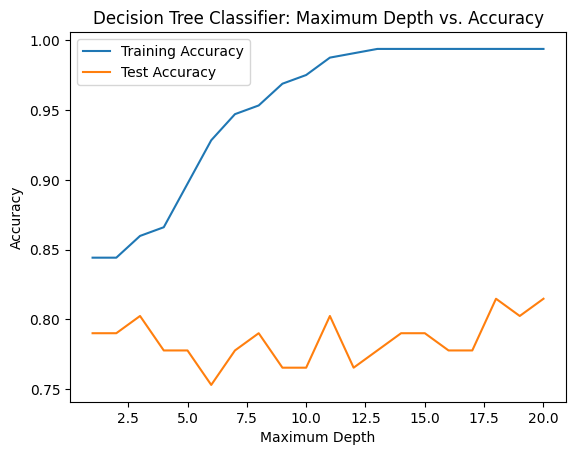

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'status' is your target column
target_col = 'status'

# Handle categorical columns
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object' and df_encoded[col].isnull().any():
        df_encoded[col].fillna(df_encoded[col].mode()[0], inplace=True)

# Handle numerical columns
for col in df_encoded.columns:
    if df_encoded[col].dtype != 'object' and df_encoded[col].isnull().any():
        imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
        df_encoded[col] = imputer.fit_transform(df_encoded[col].values.reshape(-1,1))[:,0]

# Split the data into features (X) and target (y)
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a range of maximum depths to try
max_depths = range(1, 21)

# Initialize empty lists to store the training and test accuracies for each maximum depth
train_accuracies = []
test_accuracies = []

# For each maximum depth, fit the model to the training data, make predictions on the training and test sets,
# compute the accuracies, and store them
for max_depth in max_depths:
    clf = DecisionTreeClassifier(max_depth=max_depth)
    clf.fit(X_train, y_train)

    train_pred = clf.predict(X_train)
    test_pred = clf.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

# Plot the training and test accuracies for each maximum depth
plt.plot(max_depths, train_accuracies, label='Training Accuracy')
plt.plot(max_depths, test_accuracies, label='Test Accuracy')
plt.xlabel('Maximum Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Classifier: Maximum Depth vs. Accuracy')
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)


Confusion Matrix:
 [[63  1]
 [15  2]]


True Positives (TP): These are cases where the model correctly predicted the positive class (e.g., correctly identified a disease, fraud, etc.). In your case, it’s the “2” in the bottom right corner.
True Negatives (TN): These are cases where the model correctly predicted the negative class (e.g., correctly identified non-disease, non-fraud, etc.). In your case, it’s the “63” in the top left corner.
False Positives (FP): These are cases where the model predicted positive, but the actual class was negative (e.g., predicted disease, but it wasn’t). In your case, it’s the “1” in the top right corner.
False Negatives (FN): These are cases where the model predicted negative, but the actual class was positive (e.g., missed a disease, missed fraud, etc.). In your case, it’s the “15” in the bottom left corner.
Now, let’s analyze:

If the majority class dominates the diagonal (i.e., TP and TN are large), it suggests that the model is biased toward the majority class. In your case, the majority class is “non-disease” (63 true negatives), so it might not effectively distinguish between classes.
If the minority class dominates the diagonal (i.e., TP and TN are small), it indicates that the model is performing well in terms of class separation. However, with only 2 true positives, it’s hard to draw strong conclusions about the minority class.

In [ ]:
# Make predictions on the training set
y_train_pred = model.predict(X_train)

# Evaluate the model on the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_report = classification_report(y_train, y_train_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print("Training Classification Report:\n", train_report)


Training Accuracy: 0.92
Training Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.94      0.95       271
         1.0       0.70      0.80      0.75        50

    accuracy                           0.92       321
   macro avg       0.83      0.87      0.85       321
weighted avg       0.92      0.92      0.92       321



In [ ]:
conf_matrix_train = confusion_matrix(y_train, y_train_pred)

print("Confusion Matrix (Training Set):\n", conf_matrix_train)


Confusion Matrix (Training Set):
 [[254  17]
 [ 10  40]]
